# 02. Autograd & Backpropagation

Exploring automatic differentiation with torch.autograd, compute graphs, and manual vs automatic gradient computation.

In [19]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

In [20]:
a = torch.linspace(0.0, 3.0 * math.pi, steps=25, requires_grad=True) #(Start, Stop, steps, grad required?)
print(a)

tensor([0.0000, 0.3927, 0.7854, 1.1781, 1.5708, 1.9635, 2.3562, 2.7489, 3.1416,
        3.5343, 3.9270, 4.3197, 4.7124, 5.1051, 5.4978, 5.8905, 6.2832, 6.6759,
        7.0686, 7.4613, 7.8540, 8.2467, 8.6394, 9.0321, 9.4248],
       requires_grad=True)


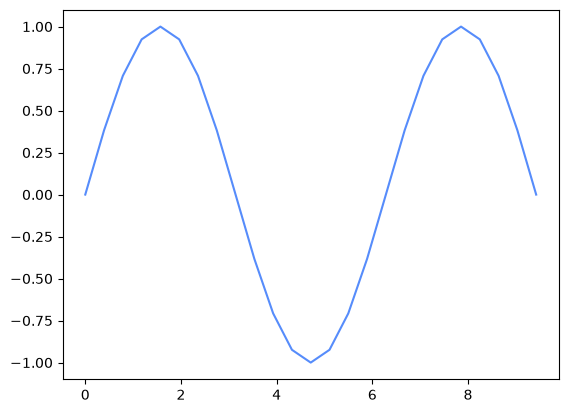

In [21]:
b = torch.sin(a)
plt.plot(a.detach(), b.detach()) #In PyTorch, the tensor.detach() method is used to separate a tensor from its computational graph. If you want to use a tensor's values without affecting gradient computations or wasting memory tracking its history, you must detach it.

In [22]:
print(b) #trackin the computation history (grad_fn=<SinBackward0>)

tensor([ 0.0000e+00,  3.8268e-01,  7.0711e-01,  9.2388e-01,  1.0000e+00,
         9.2388e-01,  7.0711e-01,  3.8268e-01, -8.7423e-08, -3.8268e-01,
        -7.0711e-01, -9.2388e-01, -1.0000e+00, -9.2388e-01, -7.0711e-01,
        -3.8268e-01, -3.0199e-07,  3.8268e-01,  7.0711e-01,  9.2388e-01,
         1.0000e+00,  9.2388e-01,  7.0711e-01,  3.8268e-01, -2.3850e-08],
       grad_fn=<SinBackward0>)


The grad_fn is an attribute of a tensor which references the specific mathematical operation used to create that tensor.


In [23]:
c = 2 * b
print(c)

d = c + 1
print(d)

tensor([ 0.0000e+00,  7.6537e-01,  1.4142e+00,  1.8478e+00,  2.0000e+00,
         1.8478e+00,  1.4142e+00,  7.6537e-01, -1.7485e-07, -7.6537e-01,
        -1.4142e+00, -1.8478e+00, -2.0000e+00, -1.8478e+00, -1.4142e+00,
        -7.6537e-01, -6.0398e-07,  7.6537e-01,  1.4142e+00,  1.8478e+00,
         2.0000e+00,  1.8478e+00,  1.4142e+00,  7.6537e-01, -4.7700e-08],
       grad_fn=<MulBackward0>)
tensor([ 1.0000,  1.7654,  2.4142,  2.8478,  3.0000,  2.8478,  2.4142,  1.7654,
         1.0000,  0.2346, -0.4142, -0.8478, -1.0000, -0.8478, -0.4142,  0.2346,
         1.0000,  1.7654,  2.4142,  2.8478,  3.0000,  2.8478,  2.4142,  1.7654,
         1.0000], grad_fn=<AddBackward0>)


In [24]:
out = d.sum()
print(out)

tensor(35.0547, grad_fn=<SumBackward0>)


In [25]:
print("d:")
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0])
print(d.grad_fn.next_functions[1])
print(d.grad_fn.next_functions[0][0].next_functions)
print(
    d.grad_fn.next_functions[0][0]
    .next_functions[0][0]
    .next_functions[0][0]
    .next_functions
    )


d:
((<MulBackward0 object at 0x0000026FED45BC40>, 0), (None, 0))
(<MulBackward0 object at 0x0000026FED45BC40>, 0)
(None, 0)
((<SinBackward0 object at 0x0000026FED5EEDD0>, 0), (None, 0))
()


In [26]:
print("c:")
print(c.grad_fn)
print("b:")
print(b.grad_fn)
print("a:")
print(a.grad_fn)

c:
b:
a:
None


tensor([ 2.0000e+00,  1.8478e+00,  1.4142e+00,  7.6537e-01, -8.7423e-08,
        -7.6537e-01, -1.4142e+00, -1.8478e+00, -2.0000e+00, -1.8478e+00,
        -1.4142e+00, -7.6537e-01,  2.3850e-08,  7.6537e-01,  1.4142e+00,
         1.8478e+00,  2.0000e+00,  1.8478e+00,  1.4142e+00,  7.6537e-01,
         2.7814e-07, -7.6537e-01, -1.4142e+00, -1.8478e+00, -2.0000e+00])


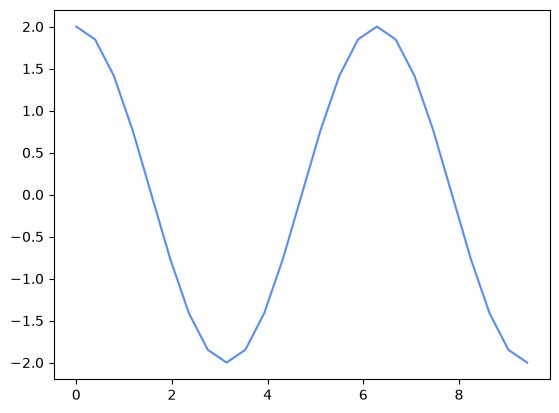

In [27]:
out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())

# RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [28]:
BATCH_SIZE = 20 # for efficiency's sake, we are feeding the model 20 batches to process in parallel rather than 1 at a time
DIM_IN = 1000 # there are 1000 features per batch (20, 1000)
HIDDEN_SIZE = 100 # the brain; we are declaring that the model will have 100 hidden nodes which it could blend the 1000 features to.
DIM_OUT = 10 #10 predictions which will be returned after trainin

class TinyModel(torch.nn.Module): #torch.nn.module is the fundamental base class for all neural network pieces in PyTorch
    def __init__(self): # core structure of a nn.module
        super(TinyModel, self).__init__()

        #define the submodule
        self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE) #Input shape [16, 1000] -> output shape [16, 100] "mix these 1000 features into 100 abstract concepts / nodes"
        self.relu = torch.nn.ReLU() # Any hidden values become 0
        self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT) # Each example's 100 hidden values gets mixed into 10 final values

    def forward(self, x): #specifying the mathematical flow and data path of the model. Pass an input x through the components and return the output
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

# Instantiate and use the model
some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False) #requires_grad=False on the data; inputs are fixed and we never # update them, so no reason to track gradients for them (saves memory and computation)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

# nn.Module automatically sets requires_grad=True on all its internal weights which is why we don't have to set that.
model = TinyModel() #instantiate the model; its weights are randomly initialized

In [29]:
#layer2.weight has shape [DIM_OUT, HIDDEN_SIZE] which is [10, 100]
print(model.layer2.weight[0][0:10]) #small slice: first row, first 10 entries
                                    # grad_fn=<SliceBackward0> appears because even indexing a tracked parameter is itself a tracked operation
print(model.layer2.weight.grad)     # None -> no backward pass has run yet, so no gradients exist

tensor([-0.0557, -0.0101, -0.0358, -0.0188, -0.0426, -0.0495,  0.0642, -0.0677,
         0.0162, -0.0854], grad_fn=<SliceBackward0>)
None


In [30]:
# SGD = Stochastic Gradient Descent, the simplest optimizer:
# after each backward pass it updates every weight as  weight = weight - lr * weight.grad
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)  # lr (learning rate) = size of each nudge step

# FORWARD PASS: push the input batch through the model to get predictions
prediction = model(some_input)  # shape [20, 10]

# LOSS = sum of squared errors ("Euclidean distance squared" between prediction and ideal_output):
# one scalar number expressing "how wrong the model is right now"
loss = (ideal_output - prediction).pow(2).sum()  # pow(2) squares each error, sum() adds them all -> scalar
print(loss)

tensor(260.6258, grad_fn=<SumBackward0>)


In [31]:
# layer2.weight has shape [DIM_OUT, HIDDEN_SIZE] = [10, 100] (out_features x in_features)
print(model.layer2.weight[0][0:10])  # just a small slice: first row, first 10 entries.
                                     # grad_fn=<SliceBackward0> appears because even *indexing* a
                                     # tracked parameter is itself a tracked operation
print(model.layer2.weight.grad)  # None -> no backward pass has run yet, so no gradients exist

tensor([-0.0557, -0.0101, -0.0358, -0.0188, -0.0426, -0.0495,  0.0642, -0.0677,
         0.0162, -0.0854], grad_fn=<SliceBackward0>)
None


In [32]:
# layer2.weight has shape [DIM_OUT, HIDDEN_SIZE] = [10, 100] (out_features x in_features)
print(model.layer2.weight[0][0:10])  # just a small slice: first row, first 10 entries.
                                     # grad_fn=<SliceBackward0> appears because even *indexing* a
                                     # tracked parameter is itself a tracked operation
print(model.layer2.weight.grad)  # None -> no backward pass has run yet, so no gradients exist

tensor([-0.0557, -0.0101, -0.0358, -0.0188, -0.0426, -0.0495,  0.0642, -0.0677,
         0.0162, -0.0854], grad_fn=<SliceBackward0>)
None


In [33]:
loss.backward()  # compute d(loss)/d(every parameter with requires_grad=True)
                 # and store the result in each parameter's .grad attribute.
                 # NOTE: this ONLY computes gradients - it does NOT change any weights.

print(model.layer2.weight[0][0:10])  # weights UNCHANGED by backward()
print(model.layer2.weight.grad[0][0:10])  # the freshly computed gradient for each weight:
                                          # direction + magnitude of the nudge that would reduce the loss

tensor([-0.0557, -0.0101, -0.0358, -0.0188, -0.0426, -0.0495,  0.0642, -0.0677,
         0.0162, -0.0854], grad_fn=<SliceBackward0>)
tensor([-2.1664,  0.7310, -3.8788,  0.7963, -7.4897, -5.0407, -4.2653, -7.7942,
        -5.2790, -0.0977])


In [34]:
a = torch.ones(2, 3, requires_grad=True)  # 2x3 tensor of ones, tracking ON
print(a)

b1 = 2 * a  # TRACKED: b1.grad_fn=<MulBackward0> because `a` required grad
print(b1)

a.requires_grad = False  # flip the switch permanently for THIS tensor
b2 = 2 * a  # NOT tracked: autograd no longer records operations on `a`
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [35]:
a = torch.ones(2, 3, requires_grad=True)  # 2x3 tensor of ones, tracking ON
print(a)

b1 = 2 * a  # TRACKED: b1.grad_fn=<MulBackward0> because `a` required grad
print(b1)

a.requires_grad = False  # flip the switch permanently for THIS tensor
b2 = 2 * a  # NOT tracked: autograd no longer records operations on `a`
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [36]:
a = torch.ones(2, 3, requires_grad=True)  # 2x3 tensor of ones, tracking ON
print(a)

b1 = 2 * a  # TRACKED: b1.grad_fn=<MulBackward0> because `a` required grad
print(b1)

a.requires_grad = False  # flip the switch permanently for THIS tensor
b2 = 2 * a  # NOT tracked: autograd no longer records operations on `a`
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [37]:
x = torch.rand(5, requires_grad=True)  # 5 random values in [0, 1), tracking ON
y = x.detach()  # y = a NEW tensor that SHARES x's underlying data buffer,
                # but carries NO link to the computation graph (requires_grad=False)

print(x)  # requires_grad=True, grad_fn present if applicable
print(y)  # a plain data-only tensor: safe to convert to NumPy, plot, or mutate

tensor([0.7384, 0.5125, 0.9692, 0.2262, 0.1792], requires_grad=True)
tensor([0.7384, 0.5125, 0.9692, 0.2262, 0.1792])


In [38]:
# Pick where to run: GPU if one is available, otherwise CPU
device = torch.device("cpu")
run_on_gpu = False
if torch.cuda.is_available():
    device = torch.device("cuda")
    run_on_gpu = True

x = torch.randn(2, 3, requires_grad=True)
y = torch.rand(2, 3, requires_grad=True)
z = torch.ones(2, 3, requires_grad=True)

# The profiler records every autograd operation executed inside the block,
# with timing - a built-in way to see WHERE your model spends its time
with torch.autograd.profiler.profile(use_device="cuda" if run_on_gpu else None) as prf:
    for _ in range(1000):
        z = (z / x) * y  # the operation whose cost we are measuring, repeated 1000x for a stable average

print(prf.key_averages().table(sort_by="self_cpu_time_total"))  # ops ranked by total self CPU time

-------------  ------------  ------------  ------------  ------------  ------------  ------------  
         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
    aten::div        56.43%       9.674ms        56.43%       9.674ms       9.674us          1000  
    aten::mul        43.57%       7.470ms        43.57%       7.470ms       7.470us          1000  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 17.144ms



In [40]:
def exp_adder(x, y):
    return 2 * x.exp() + 3 * y  # f(x, y) = 2*e^x + 3y


inputs = (torch.rand(1), torch.rand(1))  # arguments for the function
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)  # the full matrix of partial derivatives:
                                                       # [[df/dx, df/dy]] evaluated at the given inputs

(tensor([0.4352]), tensor([0.3914]))


(tensor([[3.0906]]), tensor([[3.]]))

In [41]:
inputs = (torch.rand(3), torch.rand(3))  # 3-element inputs -> the Jacobian becomes a 3x3 block per input
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.3451, 0.6181, 0.2291]), tensor([0.2637, 0.8298, 0.2344]))


(tensor([[2.8243, 0.0000, 0.0000],
         [0.0000, 3.7108, 0.0000],
         [0.0000, 0.0000, 2.5150]]),
 tensor([[3., 0., 0.],
         [0., 3., 0.],
         [0., 0., 3.]]))

In [42]:
def do_some_doubling(x):
    y = x * 2
    while y.data.norm() < 1000:
        y = y * 2
    return y


inputs = torch.randn(3)
my_gradients = torch.tensor([0.1, 1.0, 0.0001])
# vjp = vector-Jacobian product, in a single function call (the same math y.backward(v) performed above).
# Returns (function_output, vjp_result).
torch.autograd.functional.vjp(do_some_doubling, inputs, v=my_gradients)

(tensor([-951.1136, -360.5611, 1563.2689]),
 tensor([1.0240e+02, 1.0240e+03, 1.0240e-01]))